In [ ]:
import torch
import matplotlib.pyplot as plt
import scipy
from time import time

def test_function(x):
    term1 = torch.sin( 10* torch.pi * x) * torch.exp(-10 * (x - 0.5)**2)
    term2 = 0.5 * torch.cos(50 * torch.pi * x) * torch.exp(-20 * (x - 0.25)**2)
    term3 = 0.3 * torch.sin(60 * torch.pi * x) * torch.exp(-30 * (x - 0.75)**2)
    poly = 0.2 * (x - 0.5)**3
    series = sum(0.1 / (2**n) * torch.sin((2 * n + 1) * torch.pi * x) for n in range(3))
    return term1 + term2 + term3 + poly + series


def noisy_test_function(x, noise_std=0.0000001):
    y = test_function(x)
    noise = torch.randn_like(y) * noise_std
    return y + noise


#test_function = lambda x : ( tn.tensor( scipy.special.eval_chebyt(10, 2*(0.5-x.numpy())) ) )*tn.log(1+x)
x = torch.linspace(0, 1, 1000)
y = test_function(x)
plt.plot(x.numpy(), y.numpy())
plt.show()


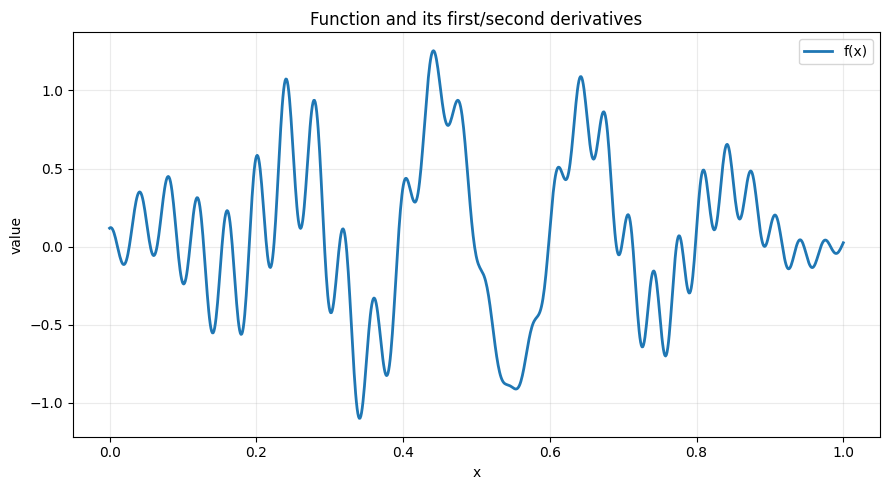

In [3]:
import torch
import matplotlib.pyplot as plt
import scipy  # (unused here; safe to remove)
from time import time

# Optional: better numerical stability
torch.set_default_dtype(torch.float64)

def test_function(x):
    term1 = torch.sin(10 * torch.pi * x) * torch.exp(-10 * (x - 0.5)**2)
    term2 = 0.5 * torch.cos(50 * torch.pi * x) * torch.exp(-20 * (x - 0.25)**2)
    term3 = 0.3 * torch.sin(60 * torch.pi * x) * torch.exp(-30 * (x - 0.75)**2)
    poly  = 0.2 * (x - 0.5)**3
    series = sum(0.1 / (2**n) * torch.sin((2 * n + 1) * torch.pi * x) for n in range(3))
    return term1 + term2 + term3 + poly + series

def noisy_test_function(x, noise_std=1e-7):
    y = test_function(x)
    noise = torch.randn_like(y) * noise_std
    return y + noise

# Domain
x = torch.linspace(0, 1, 1000, requires_grad=True)

# f(x)
y = test_function(x)

# f'(x)
dy_dx = torch.autograd.grad(
    outputs=y, inputs=x,
    grad_outputs=torch.ones_like(y),
    create_graph=True
)[0]

# f''(x)
d2y_dx2 = torch.autograd.grad(
    outputs=dy_dx, inputs=x,
    grad_outputs=torch.ones_like(dy_dx),
    create_graph=False
)[0]

# Plot all three
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x.detach().numpy(), y.detach().numpy(), label='f(x)', linewidth=2)
#ax.plot(x.detach().numpy(), dy_dx.detach().numpy(), label="f'(x)")
#ax.plot(x.detach().numpy(), d2y_dx2.detach().numpy(), label="f''(x)")
ax.set_xlabel('x')
ax.set_ylabel('value')
ax.set_title('Function and its first/second derivatives')
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [ ]:
# 1D interpolation functions

In [18]:
import numpy as np
import torchtt as tntt
import torch as tn
import teneva as ten
p_coarse = 13
p_ext = 5
x0 = tn.linspace(0, 1, 2**p_coarse+1,requires_grad=True)[0:-1]
t1 = time()
y0 = test_function(x0)
# f'(x)
dy_dx = torch.autograd.grad(
    outputs=y0, inputs=x0,
    grad_outputs=torch.ones_like(y0),
    create_graph=True
)[0]

# f''(x)
d2y_dx2 = torch.autograd.grad(
    outputs=dy_dx, inputs=x0,
    grad_outputs=torch.ones_like(dy_dx),
    create_graph=False
)[0]
fc0 = tntt.TT(y0.detach(),[2]*(p_coarse),eps=1e-14)

In [19]:
fc0

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 2, 4, 8, 16, np.int64(15), np.int64(13), np.int64(11), np.int64(9), np.int64(8), np.int64(7), 4, 2, 1]

Device: cpu, dtype: torch.float64
#entries 2026 compression 0.247314453125

In [21]:
tntt.TT(d2y_dx2.detach(),[2]*(p_coarse),eps=1e-14)

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 2, 4, 8, 16, np.int64(17), np.int64(15), np.int64(12), np.int64(9), np.int64(8), np.int64(7), 4, 2, 1]

Device: cpu, dtype: torch.float64
#entries 2302 compression 0.281005859375